## CubicSpline

Comparision with Hermite

/home/yip/miniconda3/envs/robotic_course/lib/python3.9/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.0)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


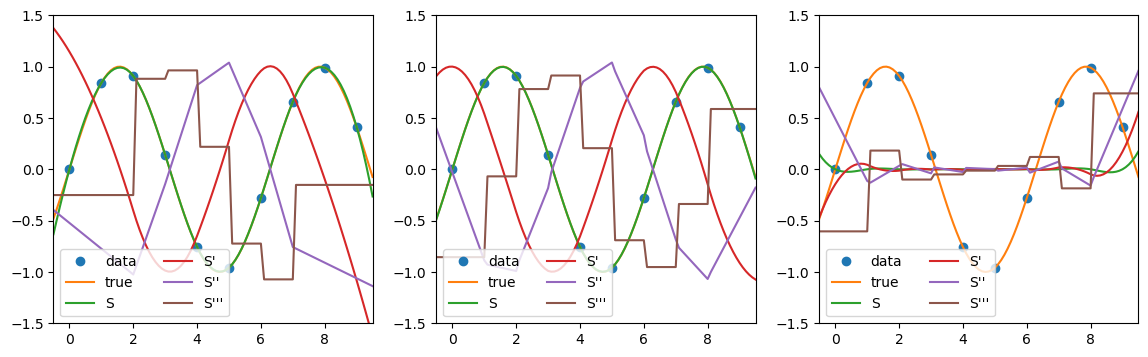

In [1]:
import numpy as np
from scipy.interpolate import CubicSpline, CubicHermiteSpline
import matplotlib.pyplot as plt
x = np.arange(10)
y = np.sin(x)
dydx = np.cos(x)
cs = CubicSpline(x, y)
chs = CubicHermiteSpline(x, y, dydx)
xs = np.arange(-0.5, 9.6, 0.1)

def drawSpline(spline, ax):
    ax.plot(x, y, 'o', label='data')
    ax.plot(xs, np.sin(xs), label='true')
    ax.plot(xs, spline(xs), label="S")
    ax.plot(xs, spline(xs, 1), label="S'")
    ax.plot(xs, spline(xs, 2), label="S''")
    ax.plot(xs, spline(xs, 3), label="S'''")
    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-1.5, 1.5)
    ax.legend(loc='lower left', ncol=2)
# CubicSpline
figs = plt.subplots(1,3,figsize=(14, 4))
ax = figs[1][0]
drawSpline(cs, ax)
# CubicHermiteSpline
ax = figs[1][1]
drawSpline(chs, ax)
# Diff
ax = figs[1][2]
difffun = lambda x, d=0: chs(x, d) - cs(x, d) if d < 4 and d > 0 else chs(x)-cs(x)
drawSpline(difffun,ax)
plt.show()

## HermiteSpline

In [2]:
import numpy as np
from scipy.interpolate import CubicSpline, CubicHermiteSpline
import matplotlib.pyplot as plt
x = np.arange(10)
y = np.sin(x)
v = np.cos(x)
chs = CubicHermiteSpline(x, y, v)
xs = np.arange(-0.5, 9.6, 0.1)
print(y)
print(chs)

[ 0.          0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427
 -0.2794155   0.6569866   0.98935825  0.41211849]


## B Spline

Scipy BSpline Class

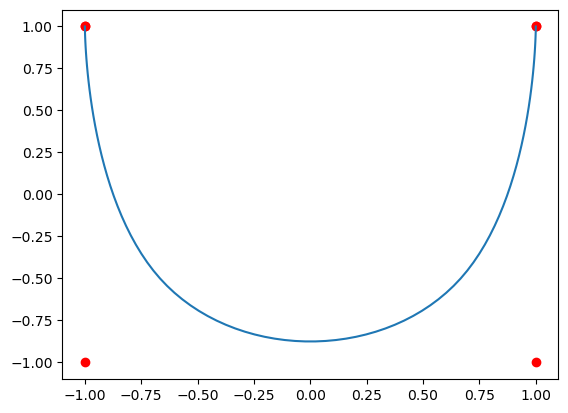

In [3]:
from scipy import interpolate
k = 3
t = [1,1,1,1,2,3,4,4,4,4]
c = [[1,1],[1,1], [1,-1], [-1,-1], [-1,1],[-1,1]]
spline = interpolate.BSpline(t, c, k, )
xs = np.linspace(1, 4, 100)
ax = plt.gca()

ax.plot(spline(xs)[:,0], spline(xs)[:,1])

ax.scatter(spline.c[:,0], spline.c[:,1], c='r')

array([ 0.   , -0.875])

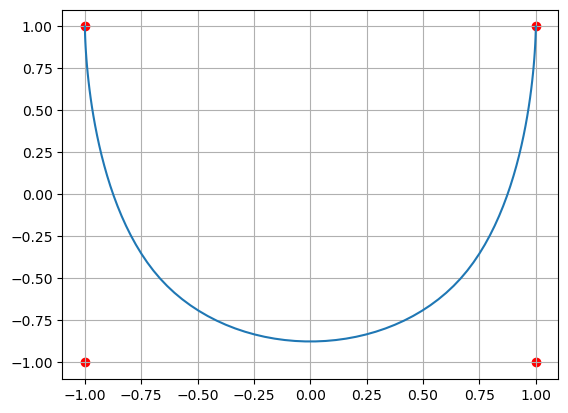

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from traj_gen import UniBSpline
# knots = np.array([[2,1],[1,-1],[0.5, 0], [0,0], [-0.5, 0], [-1,-1], [-2,1]])
knots = np.array([[1,1],[1,-1],[-1,-1], [-1,1]])

spline = UniBSpline(knots, k=3)
# spline.insert(1.5)
# spline.insert(0.1)
# spline.insert(1.1)
xs = np.linspace(spline.get_range()[0], spline.get_range()[1], 100)
ax = plt.gca()
ax.plot(spline.evaluate(xs)[:,0], spline.evaluate(xs)[:,1])
ax.scatter(spline.get()[:,0], spline.get()[:,1], c='r')
ax.grid(True)
spline.evaluate(1.5)

B Spline Interpolate

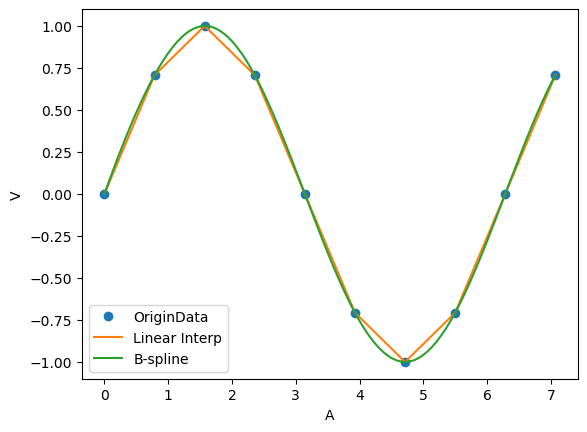

In [3]:
import numpy as np
import pylab as pl
from scipy import interpolate 
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi+np.pi/4, 10)
y = np.sin(x)

x_new = np.linspace(0, 2*np.pi+np.pi/4, 100)
f_linear = interpolate.interp1d(x, y)
tck = interpolate.splrep(x, y)
y_bspline = interpolate.splev(x_new, tck)

plt.xlabel(u'A')
plt.ylabel(u'V')

plt.plot(x, y, "o",  label="OriginData")
plt.plot(x_new, f_linear(x_new), label=u"Linear Interp")
plt.plot(x_new, y_bspline, label=u"B-spline")

pl.legend()
pl.show()

[[-6.97155403e-01  8.30837456e-01]
 [ 2.77555756e-17  1.08458127e+00]
 [ 6.97155403e-01  8.30837456e-01]
 [ 1.06810405e+00  1.88335561e-01]
 [ 9.39274934e-01 -5.42290636e-01]
 [ 3.70948642e-01 -1.01917302e+00]
 [-3.70948642e-01 -1.01917302e+00]
 [-9.39274934e-01 -5.42290636e-01]
 [-1.06810405e+00  1.88335561e-01]
 [-6.97155403e-01  8.30837456e-01]
 [ 2.77555756e-17  1.08458127e+00]
 [ 6.97155403e-01  8.30837456e-01]]
[-2.0943951  -1.3962634  -0.6981317   0.          0.6981317   1.3962634
  2.0943951   2.7925268   3.4906585   4.1887902   4.88692191  5.58505361
  6.28318531  6.98131701  7.67944871  8.37758041]


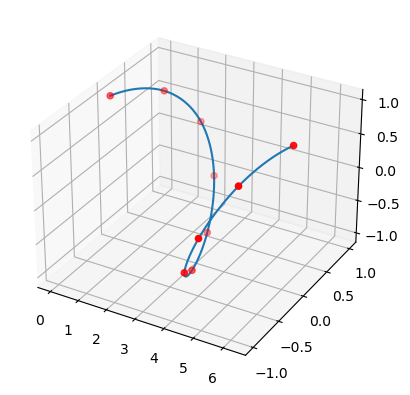

In [35]:
x = np.linspace(0, 2*np.pi, 10)
y = np.array([np.sin(x), np.cos(x)])
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, 2*np.pi, 100)
bspl = interpolate.make_interp_spline(x, y, k=3, bc_type='periodic', axis=1)
ax.plot3D(xx, *bspl(xx))
ax.scatter3D(x, *y, color='red')
print(bspl.c)
print(bspl.t)
plt.show()


16 10
[0.         0.         0.         0.         0.         0.
 1.57079633 2.0943951  2.61799388 3.14159265 4.71238898 4.71238898
 4.71238898 4.71238898 4.71238898 4.71238898] [[ 0.00000000e+00  1.00000000e+00]
 [ 3.13179557e-01  9.99287472e-01]
 [ 7.35354693e-01  8.37391303e-01]
 [ 1.10770341e+00  3.50175702e-01]
 [ 1.08435438e+00 -3.78800948e-01]
 [ 3.78800948e-01 -1.08435438e+00]
 [-3.50175702e-01 -1.10770341e+00]
 [-8.37391303e-01 -7.35354693e-01]
 [-9.99287472e-01 -3.13179557e-01]
 [-1.00000000e+00 -1.83697020e-16]]


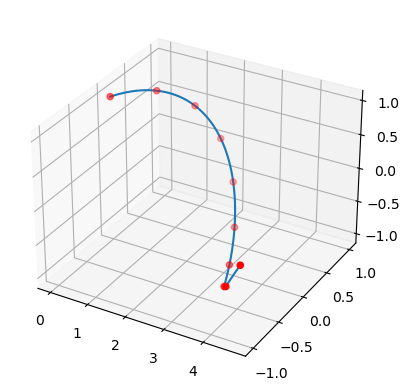

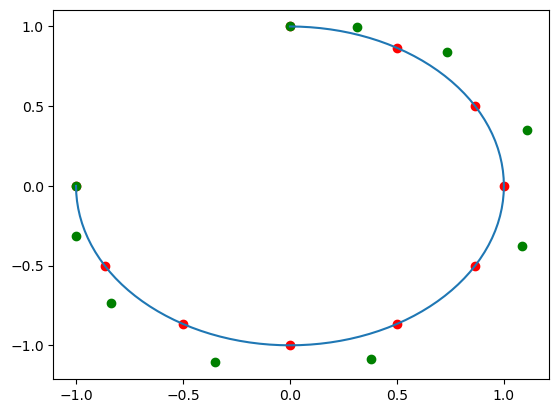

In [80]:
# 2 Dimensional
x_range = 1.5*np.pi
x = np.linspace(0, x_range, 10)
y = np.array([np.sin(x), np.cos(x)])
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, x_range, 100)
bspl = interpolate.make_interp_spline(x, y, k=5, bc_type=None, axis=1)
# print(bspl.t, "\n", bspl.c)
# bspl = interpolate.make_interp_spline(x, y, k=3, bc_type="periodic", axis=1)
ax.plot3D(xx, *bspl(xx))
# *y 将把它的元素分别传递给 ax.scatter3D 函数，每个元素将成为一个参数
ax.scatter3D(x, *y, color='red')
print(len(bspl.t), len(bspl.c))
print(bspl.t,bspl.c)
plt.show()
plt.plot(bspl(xx)[0], bspl(xx)[1], label="B-spline")
plt.scatter(y[0], y[1], color='red', label="OriginData")
plt.scatter([t[0] for t in bspl.c],[t[1] for t in bspl.c],
            color='green', label="Knots")

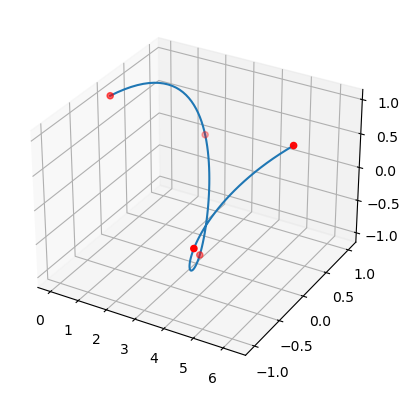

In [6]:
# 3 Dimensional

# Spline gen
x_range = 2*np.pi
x = np.linspace(0, x_range, 5)
y = np.array([x, np.sin(x), np.cos(x)])
# Periodic condition is satisfied because y coordinates of points on the ends are equivalent
ax = plt.axes(projection='3d')
xx = np.linspace(0, x_range, 100)
bspl = interpolate.make_interp_spline(x, y, k=3, bc_type=None, axis=1)
ax.plot3D(*bspl(xx))
ax.scatter3D(*y, color='red')
plt.show()

## Bezier Insertion


In [7]:
import numpy as np
from traj_gen import cubic_bezier_evaluate, bezier_evaluate, cubic_evaluate, linear_evaluate, BEZIER_MAT, HERMITE_MAT, UNI_B_MAT

### Insert a new knot(evaluated from tk) into Bezier Spline

In [8]:
tk = 0.6
para_mat = BEZIER_MAT
para_inv = np.linalg.inv(para_mat)

# Knot
P1 = np.array([0, 0, 1])
P2 = np.array([0, 1, 0])
P3 = np.array([1, 1, 0])
P4 = np.array([1, 0, 0])
P = np.array([P1, P2, P3, P4])

Pk = cubic_evaluate(P, tk, para_mat)
tk_diag = np.array([[1, 0, 0, 0],[0, tk, 0, 0],[0, 0, tk**2, 0],[0, 0, 0, tk**3]])
print(para_inv @ tk_diag @ para_mat @ P)
print("Pk:", Pk)


[[0.    0.    1.   ]
 [0.    0.6   0.4  ]
 [0.36  0.84  0.16 ]
 [0.648 0.72  0.064]]
Pk: [0.648 0.72  0.064]


### Insert a knot into Hermite spline
This is easy because Hermite & Bezier can convert to each other

IMPORTANT: This velocity of knot at two side is different

P_new: [[-1.38555833e-16 -2.38031816e-16  1.00000000e+00]
 [ 0.00000000e+00  6.00000000e+00  0.00000000e+00]
 [ 9.36000000e-01  1.60800000e+00  3.52000000e-01]
 [ 1.00800000e+00 -1.05600000e+00 -8.64000000e-01]]
Pk: [0.936 1.608 0.352]
P_new2: [[ 9.36000000e-01  1.60800000e+00  3.52000000e-01]
 [ 6.72000000e-01 -7.04000000e-01 -5.76000000e-01]
 [ 1.00000000e+00  1.00000000e+00 -5.21064673e-17]
 [-8.00000000e-01 -0.00000000e+00 -0.00000000e+00]]


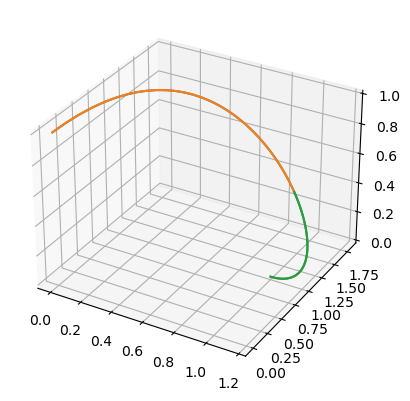

In [33]:
tk = 0.6
para_mat = HERMITE_MAT
para_inv = np.linalg.inv(para_mat)

# Knot
P1 = np.array([0, 0, 1])
V1 = np.array([0, 10, 0])
P2 = np.array([1, 1, 0])
V2 = np.array([-2, 0, 0])
P = np.array([P1, V1, P2, V2])

Pk = cubic_evaluate(P, tk, para_mat)
tk_diag = np.array([[1, 0, 0, 0],[0, tk, 0, 0],[0, 0, tk**2, 0],[0, 0, 0, tk**3]])
P_new = para_inv @ tk_diag @ para_mat @ P
print("P_new:", P_new)
print("Pk:", Pk)
# This method failed
# tk_diag2 = np.array([[1, tk, tk**2, tk**3],
#                     [0, 1-tk, 2*tk*(1-tk), 3*tk**2*(1-tk)], 
#                     [0, 0, 2*(1-tk)**2, 3*tk*(1-tk)**2],
#                     [0, 0, 0, (1-tk)**3]])
# P_new2 = (para_inv @ tk_diag2 @ para_mat @ P)
# print("P_new2:", P_new2)

# Invert curve method
P_inv = np.array([P2, -V2, P1, -V1]) 
tk_inv = 1-tk
tk_diag_inv = np.array([[1, 0, 0, 0],[0, tk_inv, 0, 0],[0, 0, tk_inv**2, 0],[0, 0, 0, tk_inv**3]])
P_new_inv = para_inv @ tk_diag_inv @ para_mat @ P_inv
# print("P_new_inv:", P_new_inv)
# print("Pk_inv:", Pk)
P_new2 = np.array([P_new_inv[2], -P_new_inv[3], P_new_inv[0], -P_new_inv[1]])
print("P_new2:", P_new2)

resolution = 50
ts = np.linspace(0, 1, resolution)
# Plot

ax = plt.subplot(1,1,1, projection='3d')
ax.plot3D(*cubic_evaluate(P, ts, para_mat).T)
ax.plot3D(*cubic_evaluate(P_new, ts, para_mat).T)
ax.plot3D(*cubic_evaluate(P_new2, ts, para_mat).T)

## Test

In [4]:
P1 = np.array([0, 0, 1])
P2 = np.array([0, 1, 0])
linear_evaluate(np.array([P1, P2]), 1)

array([[0., 1., 0.]])